<a href="https://colab.research.google.com/github/sskarthik567/ML-Algorithms/blob/main/Credit_Card_Default_Prediction_Using_Logistic_Regression_With_Data_Viz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [2]:
from google.colab import files
data=files.upload()

Saving default of credit card clients.xls to default of credit card clients.xls


In [43]:
df = pd.read_excel("default of credit card clients.xls",header=1)

In [44]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [9]:
df.shape

(30001, 25)

In [45]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')

In [48]:
df = df.rename(
    columns={"default payment next month": "default"}
)

In [49]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [50]:
df.isnull().sum()

,0
ID,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0


In [51]:
df.isnull().sum().sum()

np.int64(0)

In [52]:
df = df.drop_duplicates()

In [53]:
df["default"].value_counts()

,count
default,
0,23364
1,6636


In [54]:
df["default"].value_counts(normalize=True) * 100

,proportion
default,
0,77.88
1,22.12


In [55]:
df["default"].value_counts(normalize=True) * 100

,proportion
default,
0,77.88
1,22.12


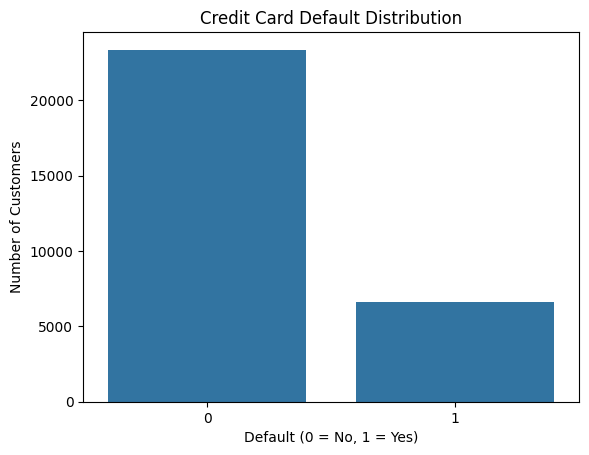

In [56]:
sns.countplot(x="default", data=df)

plt.title("Credit Card Default Distribution")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

In [58]:
df["AGE"] = df["AGE"].astype(str)

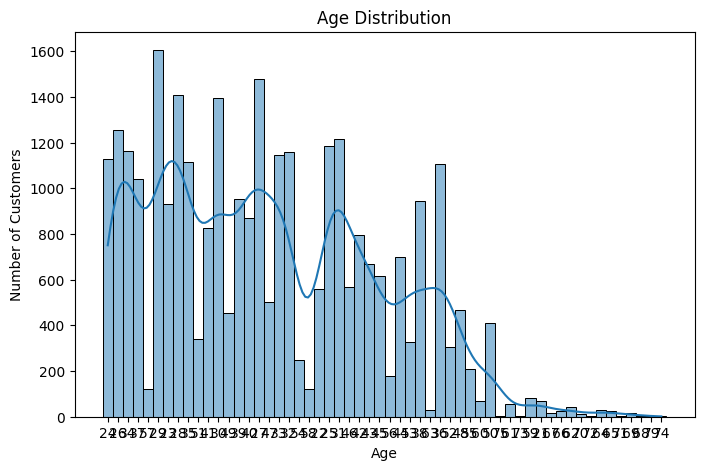

In [59]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="AGE",
    bins=20,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

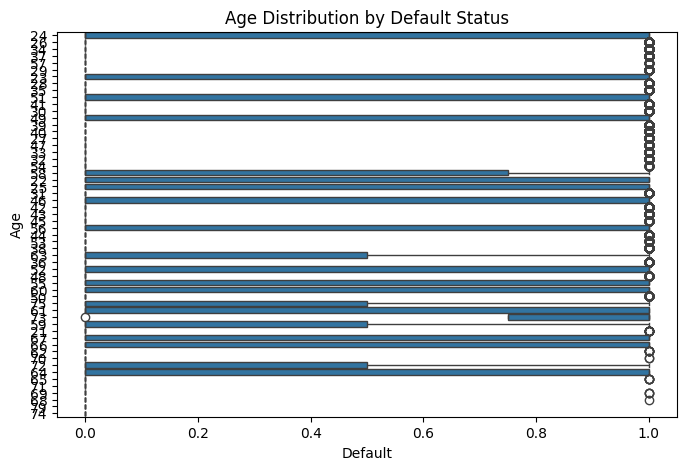

In [60]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="default",
    y="AGE",
    data=df
)

plt.title("Age Distribution by Default Status")
plt.xlabel("Default")
plt.ylabel("Age")

plt.show()

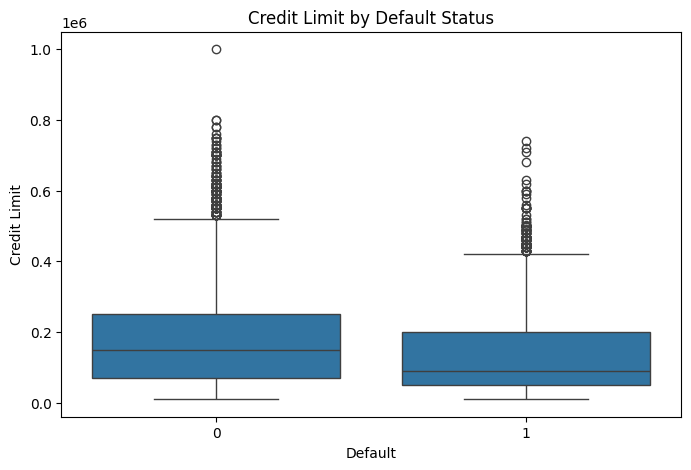

In [61]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="default",
    y="LIMIT_BAL",
    data=df
)

plt.title("Credit Limit by Default Status")
plt.xlabel("Default")
plt.ylabel("Credit Limit")

plt.show()

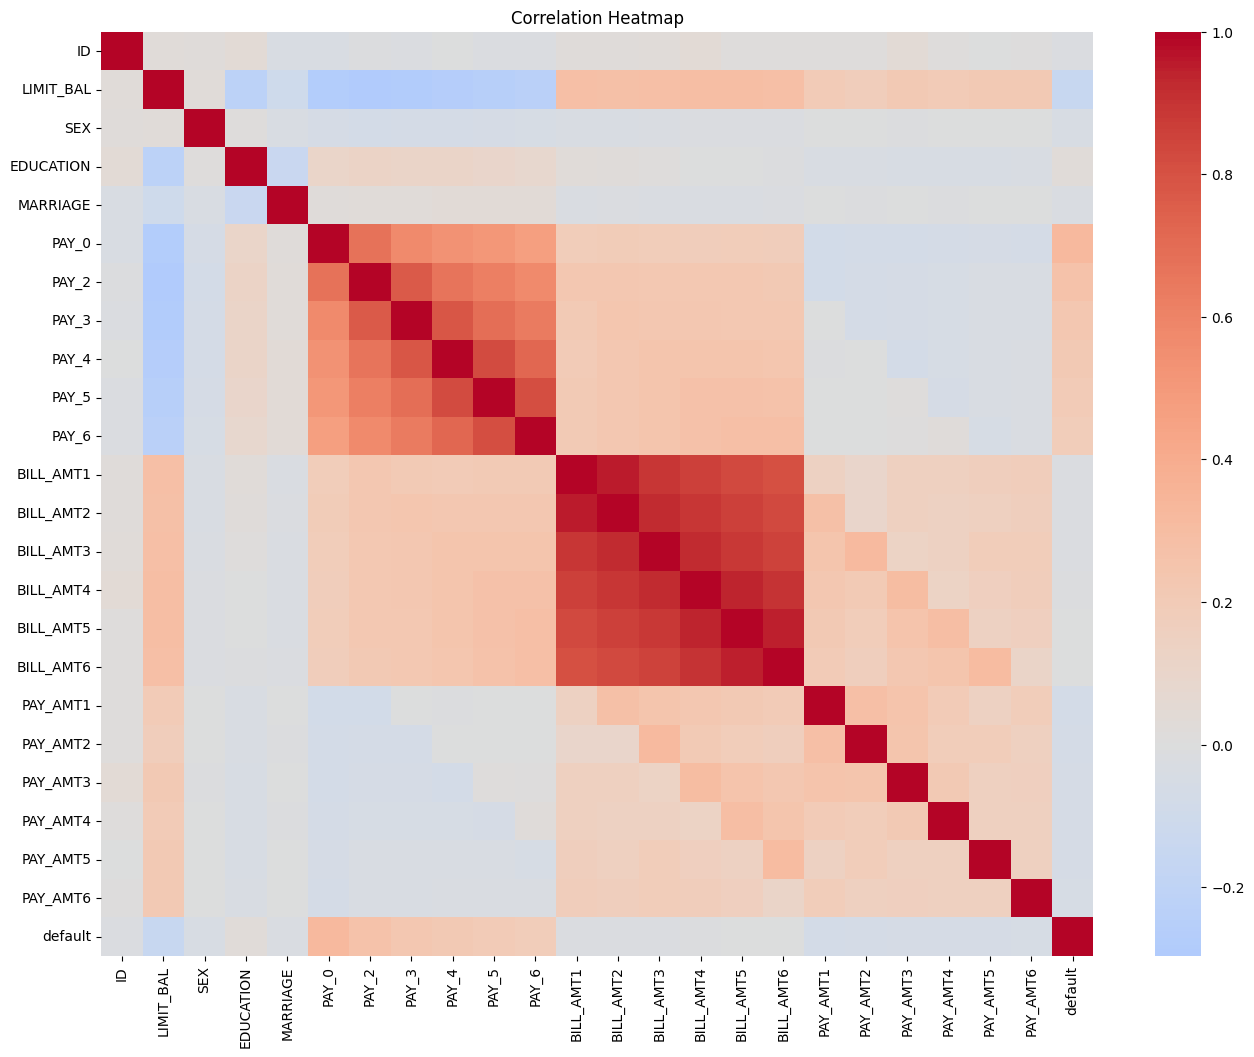

In [62]:
plt.figure(figsize=(16, 12))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

In [63]:
y = df["default"]

In [64]:
X = df.drop("default", axis=1)

In [65]:
X = df.drop("default", axis=1)

In [66]:
print(X.shape)
print(y.shape)

(30000, 24)
(30000,)


In [67]:
X = X.drop("ID", axis=1)

In [69]:
X.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [71]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [73]:
model = LogisticRegression(
    max_iter=1000
)

In [75]:
model.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=1000)

In [76]:
y_pred = model.predict(X_test_scaled)

In [77]:
print(y_pred[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [78]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.8076666666666666


In [79]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[4528  145]
 [1009  318]]


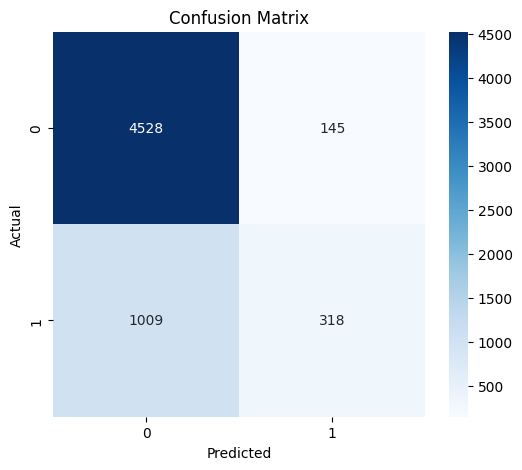

In [80]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [81]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.69      0.24      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.75      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000



In [82]:
y_probability = model.predict_proba(
    X_test_scaled
)

In [83]:
print(y_probability[:5])

[[0.89078504 0.10921496]
 [0.88331461 0.11668539]
 [0.77980226 0.22019774]
 [0.90339489 0.09660511]
 [0.97249002 0.02750998]]


In [84]:
default_probability = y_probability[:, 1]

print(default_probability[:10])

[0.10921496 0.11668539 0.22019774 0.09660511 0.02750998 0.20087738
 0.13159178 0.15358892 0.07595841 0.19481887]


In [85]:
auc = roc_auc_score(
    y_test,
    default_probability
)

print("ROC-AUC:", auc)

ROC-AUC: 0.7076355036089734


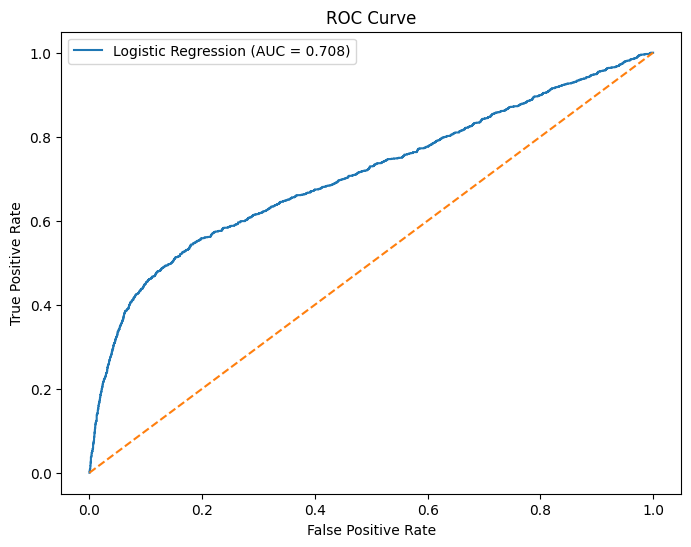

In [87]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    default_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [90]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

print(coefficients)

      Feature  Coefficient
5       PAY_0     0.660990
7       PAY_3     0.097205
6       PAY_2     0.093100
12  BILL_AMT2     0.092931
4         AGE     0.073843
8       PAY_4     0.060404
13  BILL_AMT3     0.048264
14  BILL_AMT4     0.038807
15  BILL_AMT5     0.027209
10      PAY_6     0.017985
9       PAY_5    -0.000664
16  BILL_AMT6    -0.002365
21   PAY_AMT5    -0.022492
22   PAY_AMT6    -0.028881
19   PAY_AMT3    -0.031697
20   PAY_AMT4    -0.038004
1         SEX    -0.055960
3    MARRIAGE    -0.072513
2   EDUCATION    -0.097310
0   LIMIT_BAL    -0.133241
18   PAY_AMT2    -0.179648
17   PAY_AMT1    -0.202172
11  BILL_AMT1    -0.316203


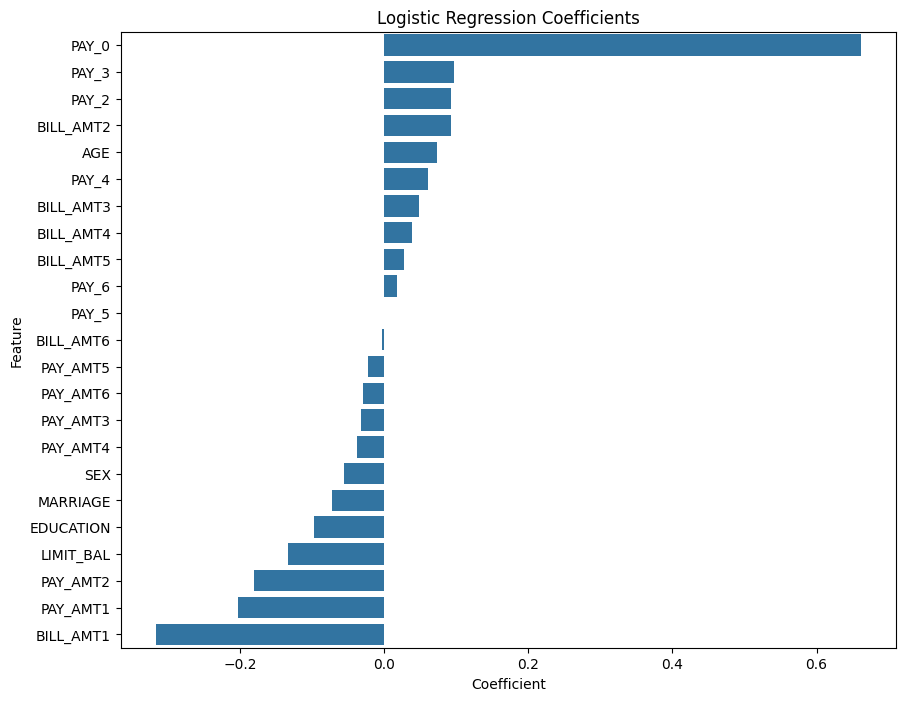

In [91]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=coefficients,
    x="Coefficient",
    y="Feature"
)

plt.title("Logistic Regression Coefficients")

plt.show()

In [92]:
new_customer = X.iloc[[0]]

In [93]:
new_customer_scaled = scaler.transform(
    new_customer
)

In [94]:
prediction = model.predict(
    new_customer_scaled
)

probability = model.predict_proba(
    new_customer_scaled
)[:, 1]

print("Prediction:", prediction[0])
print("Default Probability:", probability[0])

Prediction: 1
Default Probability: 0.5112286582743187
